In [ ]:
import pandas as pd
import numpy as np
import os
from functools import reduce
from scipy import stats
import cvxpy as cp
from datetime import datetime
from collections import defaultdict
import pickle

srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base"
adir = "E:/SJTU/实习/国泰海通/barra因子/result"
spedir = "E:/SJTU/实习/国泰海通/barra因子/result"

def orthogonalize_pair(df, col1, col2):
    x1 = df[col1].values
    x2 = df[col2].values
    
    beta = np.dot(x1, x2) / np.dot(x1, x1)
    x2_new = x2 - beta * x1
    
    df[col2] = x2_new
    return df

files = sorted(os.listdir(f"{srcdir}/base_data/whole_mkt")) #2025-01-01 ~ 2026-03-25
mcp_dict = pd.read_pickle(f"{srcdir}/stk_mcp/全A_freemcp_25_26D_dict.pkl")
return_dict = pd.read_pickle(f"{srcdir}/stk_ret/全A_ret_24_2603D_dict.pkl")
alpha_dict = pd.read_pickle(f"{adir}/延迟alpha/ortho_delay_measures_2024_2026_dict.pkl")
alpha_name = "D1_orth"#"DELAY"#'MACD_HIST'
#lam = 1
slope, intercept = 0.0674, 0.0793
num_ori = 100
pair_lst = [['earnings_yield', 'liquidity'],['beta', 'residual_volatility'],['non_linear_size', 'size']]
rou_list = [-0.308,0.357,0.510] #根据pair_lst去查数
with open(f"{srcdir}/index_component_日频/000905.XSHG_20_26D_dict.pkl", 'rb') as f:
    weight_dict = pickle.load(f) #series

ret_dict = defaultdict(list)#{}
dual_dict = defaultdict(list) #测试lam取值的时候改！
error_dt = defaultdict(list)
lam_lst = []
reg_lst = []


for i in range(1,len(files)-1): #len(files)-1
    # if w0 is None:

    #明确时间域
    alpha_dt = files[i]#"2025-04-10.pkl"#
    alpha_dt_tp = pd.to_datetime(alpha_dt.split(".pkl")[0])
    base_dt = pd.to_datetime(files[i+1].split(".pkl")[0])#dt + ".pkl"#
    before_dt = pd.to_datetime(files[i-1].split(".pkl")[0])
    print(f"获取{alpha_dt[:10]}天的因子数据并收盘买入，{base_dt}天卖出")

    #读取数据，最优化
    #df_base = pd.read_pickle(f"{srcdir}/base_data/whole_mkt/{base_dt}")
    df_mcp = mcp_dict[alpha_dt_tp] #其实用不到，因子协方差是时序数据
    df_retb = return_dict[before_dt].droplevel("date").rename(columns={"value":"retb"})
    df_ret = return_dict[base_dt].droplevel("date").rename(columns={"value":"ret"})
    df_alpha = alpha_dict[alpha_dt_tp]
    df_barra = pd.read_pickle(f"{srcdir}/barra_data/whole_mkt/{alpha_dt}") #000905标准化2
    X_center = pd.read_pickle(f"{srcdir}/barra_data/000905标准化3_含行业/{alpha_dt}") #
    variance_frq = pd.read_pickle(f"{srcdir}/fac_ret_cov/{alpha_dt}")
    variance_rq = pd.read_pickle(f"{srcdir}/spe_ret_cov/{alpha_dt}")
    weight_index = weight_dict[alpha_dt_tp]

    df_base = df_mcp.merge(df_ret,on="order_book_id")
    #df_base['order_book_id'] = df_base['code'].str.replace('.SZ','.XSHE').str.replace('.SH','.XSHG')

    dfs = [df_alpha,df_barra,df_base,df_retb]
    df_reg = reduce(lambda left, right:left.merge(right,on="order_book_id"),dfs)    #t天的alpha、因子暴露和t+1天的收益
    weight_bmk = df_reg.merge(weight_index,on="order_book_id",how="left")["weight"]
    weight_bmk = weight_bmk.fillna(0)

    #单因子收益率对齐
    # Rhat_series = (intercept + slope * df_reg[alpha_name])
    # Rhat = Rhat_series.fillna(Rhat_series.median()).values
    n_group = 50
    df_reg['group'] = pd.qcut(df_reg[alpha_name].rank(), q=n_group, labels=False)
    Rhat = df_reg['group'].map(
        df_reg.groupby('group').apply(lambda g: np.average(g['retb'], weights=g['free_mkp']))
    )
    Num = len(df_reg)

    orth_order = [x for x in variance_frq.index.tolist()[:11] if x != "comovement"]#["beta","momentum","size","non_linear_size","residual_volatility","liquidity","book_to_price","earnings_yield","growth","leverage"]
    ind_order = list(variance_frq.columns[11:].values)
    X_original = df_reg[orth_order+ind_order].values #风格+行业
    stk_order = df_reg["order_book_id"].tolist()
    #部分正交化
    flat_pair = [item for sublist in pair_lst for item in sublist]
    non_orth = [var for var in orth_order if var not in flat_pair]
    num_non = len(non_orth) #non_orth + ind_order / non_orth
    X_center =X_center.set_index("order_book_id").loc[stk_order, non_orth + flat_pair] #ind_order + 
    for c1, c2 in pair_lst:
        X_center = orthogonalize_pair(X_center, c1, c2)
    X_center = X_center.values
    # X_center = X_center.set_index("order_book_id").loc[stk_order,orth_order].values #风格

    # w_m = np.sqrt(df_reg.free_mkp.values)
    # w_m = w_m / w_m.sum()
    #X_orth = weighted_orthogonize(X_ori,w_m)
    #F_cov = variance_frq.loc[orth_order + ind_order, orth_order + ind_order].values#orthogonized_factor_cov(X_orth,w_m)
    #D_diag = variance_rq.reindex(df_reg["code"]).values.ravel()
    #sqrtD = np.sqrt(D_diag)

    #根据barra做进一步完善
    F_cov_raw = variance_frq.loc[orth_order + ind_order, orth_order + ind_order].values
    diag = np.diag(np.diag(F_cov_raw))
    F_cov = 0.9 * F_cov_raw + 0.1 * diag
    D_diag = variance_rq.reindex(df_reg["order_book_id"]).values.ravel()
    lower = np.percentile(D_diag, 1)
    upper = np.percentile(D_diag, 99)
    D_diag = np.clip(D_diag, lower, upper)
    sqrtD = np.sqrt(D_diag)
    w0 = np.ones(len(D_diag)) / len(D_diag)
    risk = w0 @ X_original @ F_cov @ X_original.T @ w0 + w0 @ np.diag(D_diag) @ w0
    ret  = np.mean(np.abs(Rhat))
    lam0 = ret / risk
    lam_lst.append(lam0)
    print(f"{base_dt}选择的lam：{lam0}")

    #R_cov = X_orth @ F_cov @ X_orth.T
    #设置权重向量的初始值【根据因子信号/等权】
    # w_ori = np.zeros_like(Rhat)
    # idx = np.argsort(Rhat)[::-1][:num_ori]
    # w_ori[idx] = np.exp(-np.arange(num_ori)/20)
    # w_ori /= w_ori.sum()
    
    print(f"开始最优化{base_dt}组合 | {datetime.now()}")
    #turnover = 0.005
    w = cp.Variable(Num)
    w.value = np.zeros_like(Rhat)
    Xo = X_original.T @ w
    Xp = X_center.T @  (w + weight_bmk)
    lam = cp.Parameter(nonneg=True,value=lam0) #lam0
    #penalty = cp.sum_squares(cp.pos(Xp - x_max)) + cp.sum_squares(cp.pos(x_min - Xp))
    #gamma = cp.Parameter(nonneg=True)
    
    objective = cp.Minimize(
            lam * (cp.quad_form(Xo, F_cov) + cp.sum_squares(cp.multiply(sqrtD, w))) - cp.sum(cp.multiply(Rhat, w)) #+ gamma*penalty
        )

    for l_val in [0.01,0.1,0.3,0.5,1]:#[0.01,0.1,0.3,0.5,1]:
        #gamma.value = l_val
        x_min = [-l_val] * num_non #[-0.1] * len(ind_order) +
        x_max = [l_val] * num_non
        for i, (c1, c2) in enumerate(pair_lst):
            current_rou2 = (rou_list[i])**2  # 取出当前配对的 rou
            x_min.append(-l_val),x_min.append(-l_val * np.sqrt((1 - current_rou2)))
            x_max.append( l_val),x_max.append(-l_val * np.sqrt((1 - current_rou2)))
        # x_min = np.full(X_center.shape[1], -l_val) #偏离 个标准差
        # x_max = np.full(X_center.shape[1], l_val)
        constraints = [
            cp.sum(w+weight_bmk) == 1,
            w + weight_bmk >= 0,
            #w <= 0.01,
            # #cp.abs(w - w0) <= turnover,
            Xp >= x_min,
            Xp <= x_max
        ]
        prob = cp.Problem(objective, constraints)
        try:
            prob.solve(solver=cp.OSQP,max_iter=50000,warm_start=True,verbose=False) #solver=cp.OSQP, #verbose=True #max_iter=10000,

            if w.value is None or np.any(np.isnan(w.value)):
                print(f"{base_dt}权重为空{prob.status}，等权买入")
                error_dt[l_val].append(f"{prob.status}_{base_dt}")
                w_opt = np.full(Num, 1/Num)
            else:
                dual_dict[l_val].append([constraints[i].dual_value for i in range(len(constraints))])
                w_opt = w.value

        except:
            print(f"{base_dt}最优化失败，等权买入")
            error_dt[l_val].append(base_dt)
            w_opt = np.full(Num, 1/Num)
    

        R_true = df_reg.ret.values
        Rp_realized = w_opt @ R_true
        #ret_dict[base_dt]=Rp_realized
        ret_dict[l_val].append(Rp_realized)

    print(f"完成最优化 | {datetime.now()}")

    #更新收益率对齐系数
    # x = df_reg[alpha_name]
    # y = df_reg['ret']
    # q_x_low, q_x_high, q_y_low, q_y_high = x.quantile(0.05), x.quantile(0.95), y.quantile(0.05), y.quantile(0.95)

    # # 过滤数据
    # df_clean = df_reg[
    #     (df_reg[alpha_name] >= q_x_low) & (df_reg[alpha_name] <= q_x_high) &
    #     (df_reg['ret'] >= q_y_low) & (df_reg['ret'] <= q_y_high)
    # ]

    # x_clean = df_clean[alpha_name]
    # y_clean = df_clean['ret']

    # #print(f"原始数据量：{len(df_reg)} → 清洗后数据量：{len(df_clean)}")

    # # 线性拟合（得到斜率、截距）
    # slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    # reg_lst.append([alpha_dt,slope, intercept, r_value**2, p_value, std_err])
    


获取2025-01-03天的因子数据并收盘买入，2025-01-06 00:00:00天卖出
2025-01-06 00:00:00选择的lam：1.1357590885122444
开始最优化2025-01-06 00:00:00组合 | 2026-04-25 20:12:05.358277


C:\Windows\Temp\ipykernel_75296\2043569803.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('group').apply(lambda g: np.average(g['retb'], weights=g['free_mkp']))
C:\Windows\Temp\ipykernel_75296\2043569803.py:163: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.OSQP,max_iter=50000,warm_start=True,verbose=False) #solver=cp.OSQP, #verbose=True #max_iter=10000,
C:\Windows\Temp\ipykernel_75296\2043569803.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping column

完成最优化 | 2026-04-25 20:12:25.573515
获取2025-01-06天的因子数据并收盘买入，2025-01-07 00:00:00天卖出
2025-01-07 00:00:00选择的lam：1.128357600993111
开始最优化2025-01-07 00:00:00组合 | 2026-04-25 20:12:25.650183


C:\Windows\Temp\ipykernel_75296\2043569803.py:163: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.OSQP,max_iter=50000,warm_start=True,verbose=False) #solver=cp.OSQP, #verbose=True #max_iter=10000,
C:\Windows\Temp\ipykernel_75296\2043569803.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('group').apply(lambda g: np.average(g['retb'], weights=g['free_mkp']))


完成最优化 | 2026-04-25 20:12:47.083993
获取2025-01-07天的因子数据并收盘买入，2025-01-08 00:00:00天卖出
2025-01-08 00:00:00选择的lam：0.18613124240086346
开始最优化2025-01-08 00:00:00组合 | 2026-04-25 20:12:47.162122


...

C:\Windows\Temp\ipykernel_75296\2043569803.py:163: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.OSQP,max_iter=50000,warm_start=True,verbose=False) #solver=cp.OSQP, #verbose=True #max_iter=10000,
C:\Windows\Temp\ipykernel_75296\2043569803.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reg.groupby('group').apply(lambda g: np.average(g['retb'], weights=g['free_mkp']))


完成最优化 | 2026-04-25 22:09:26.668827
获取2026-03-24天的因子数据并收盘买入，2026-03-25 00:00:00天卖出
2026-03-25 00:00:00选择的lam：3.6476193786523714
开始最优化2026-03-25 00:00:00组合 | 2026-04-25 22:09:26.874571


C:\Windows\Temp\ipykernel_75296\2043569803.py:163: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.OSQP,max_iter=50000,warm_start=True,verbose=False) #solver=cp.OSQP, #verbose=True #max_iter=10000,


完成最优化 | 2026-04-25 22:09:51.594963


IndexError: list index out of range

In [38]:
#测一下delay与barra因子相关系数
res = {}
for i in range(len(files)-1):
    alpha_dt = files[i]#"2025-04-10.pkl"#
    alpha_dt_tp = pd.to_datetime(alpha_dt.split(".pkl")[0])
    df_barra = pd.read_pickle(f"{srcdir}/barra_data/whole_mkt/{alpha_dt}").set_index("order_book_id").iloc[:,1:11] #000905标准化2
    df_D = alpha_dict[alpha_dt_tp][["D1_orth"]]
    df_corr = df_D.merge(df_barra,on="order_book_id")
    corr = df_corr.iloc[:,1:].corrwith(df_corr.iloc[:,0])#df_corr["D1"].corr(df_corr["size"])
    res[alpha_dt[:10]] = corr
    #print(alpha_dt)
res_df = pd.DataFrame(res).T
t = stats.ttest_1samp(res_df, 0)[0]
print(res_df.mean(),res_df.abs().mean(),t)
res_df.to_excel(f"{spedir}/组合优化/delay正交与barra因子的时序相关系数.xlsx")

size                  -0.018441
non_linear_size       -0.006734
momentum               0.040494
liquidity             -0.013325
book_to_price         -0.012611
leverage               0.014198
growth                -0.016409
earnings_yield         0.007425
beta                  -0.018032
residual_volatility   -0.002280
dtype: float64 size                   0.059012
non_linear_size        0.032488
momentum               0.047760
liquidity              0.037492
book_to_price          0.033030
leverage               0.029486
growth                 0.036255
earnings_yield         0.027502
beta                   0.018471
residual_volatility    0.008388
dtype: float64 [ -4.2618704   -2.75609489  15.54511576  -5.15423482  -5.52685762
   7.34406973  -6.44096914   3.84119096 -33.9126192   -4.1301396 ]


In [2]:
#print(len(error_dt))
print([len(error_dt[l_val]) for l_val in [0.01,0.1,0.3,0.5,1]])
print(orth_order)
print(X_center.T @ w_opt)
error_dt

[0, 0, 0, 0, 0]
['beta', 'book_to_price', 'earnings_yield', 'growth', 'leverage', 'liquidity', 'momentum', 'non_linear_size', 'residual_volatility', 'size']
[-0.09917916 -0.36605286 -0.68773714 -0.89616191 -0.94222279 -0.46543316
  0.33035139 -0.9505694  -0.05363671 -2.32789768]


defaultdict(list, {0.01: [], 0.1: [], 0.3: [], 0.5: [], 1: []})

In [3]:
#进一步剖析策略优化情况
#prob.solver_stats
num_lst = []
res_dict = []
for l_val, day_list in dual_dict.items():
    # 直接遍历每一天（每个元素就是【当天的4个约束值】）
    for dt, daily_vals in zip(files[1:], day_list):
        # 解包当天4个值（按你原来的顺序：0,1,2,3）
        val0, val1, val2, val3 = daily_vals

        num_lst.append(len(np.where(val1 == 0)[0]))

        val2 = val2.astype(float)
        if val2.max() != 0:
            idx = np.where(val2 > 0)[0]
            factors = [(orth_order)[i] for i in idx] #加行业 ind_order + orth_order #orth_order
            res_dict.append([l_val, dt[:10], "lower_bond"]+[factors])
            print(f"{dt}天的{factors}风格因子【下限】紧约束")
        val3 = val3.astype(float)
        if val3.max() != 0:
            idx = np.where(val3 > 0)[0]
            factors_u = [(orth_order)[i] for i in idx] #加行业 ind_order + orth_order
            res_dict.append([l_val, dt[:10], "upper_bond"]+[factors_u])
            print(f"{dt}天的{factors_u}风格因子【上限】紧约束")
print(f"策略平均每日配股{np.mean(num_lst),np.median(num_lst)}")
res_dict

2025-01-03.pkl天的['beta', 'earnings_yield', 'liquidity', 'momentum', 'non_linear_size']风格因子【下限】紧约束
2025-01-03.pkl天的['beta', 'book_to_price', 'growth', 'leverage', 'liquidity', 'non_linear_size', 'residual_volatility', 'size']风格因子【上限】紧约束
2025-01-06.pkl天的['beta', 'earnings_yield', 'leverage', 'liquidity', 'momentum', 'non_linear_size', 'residual_volatility', 'size']风格因子【下限】紧约束
2025-01-06.pkl天的['beta', 'book_to_price', 'growth', 'leverage', 'liquidity', 'non_linear_size', 'residual_volatility', 'size']风格因子【上限】紧约束
2025-01-07.pkl天的['book_to_price', 'earnings_yield', 'growth', 'leverage', 'liquidity', 'momentum', 'residual_volatility', 'size']风格因子【下限】紧约束
2025-01-07.pkl天的['beta', 'book_to_price', 'growth', 'leverage', 'liquidity', 'momentum', 'non_linear_size', 'size']风格因子【上限】紧约束
2025-01-08.pkl天的['earnings_yield', 'liquidity', 'momentum', 'residual_volatility']风格因子【下限】紧约束
2025-01-08.pkl天的['beta', 'book_to_price', 'growth', 'leverage', 'non_linear_size', 'size']风格因子【上限】紧约束
2025-01-09.pkl天的['ear

[[0.01,
  '2025-01-03',
  'lower_bond',
  ['beta', 'earnings_yield', 'liquidity', 'momentum', 'non_linear_size']],
 [0.01,
  '2025-01-03',
  'upper_bond',
  ['beta',
   'book_to_price',
   'growth',
   'leverage',
   'liquidity',
   'non_linear_size',
   'residual_volatility',
   'size']],
 [0.01,
  '2025-01-06',
  'lower_bond',
  ['beta',
   'earnings_yield',
   'leverage',
   'liquidity',
   'momentum',
   'non_linear_size',
   'residual_volatility',
   'size']],
 [0.01,
  '2025-01-06',
  'upper_bond',
  ['beta',
   'book_to_price',
   'growth',
   'leverage',
   'liquidity',
   'non_linear_size',
   'residual_volatility',
   'size']],
 [0.01,
  '2025-01-07',
  'lower_bond',
  ['book_to_price',
   'earnings_yield',
   'growth',
   'leverage',
   'liquidity',
   'momentum',
   'residual_volatility',
   'size']],
 [0.01,
  '2025-01-07',
  'upper_bond',
  ['beta',
   'book_to_price',
   'growth',
   'leverage',
   'liquidity',
   'momentum',
   'non_linear_size',
   'size']],
 [0.01,
  

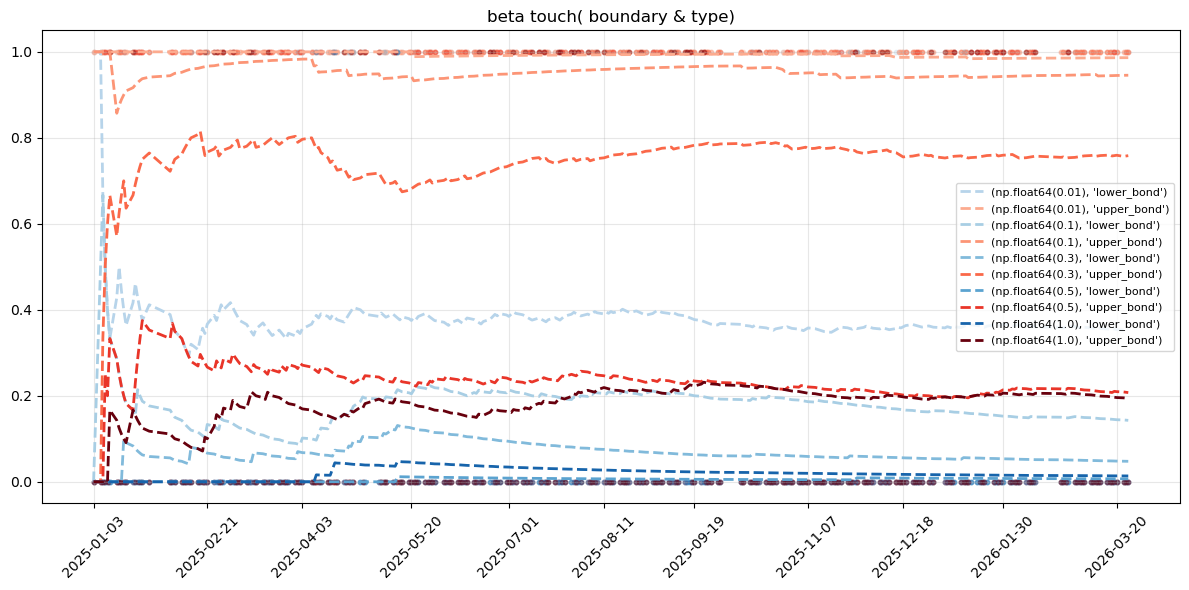

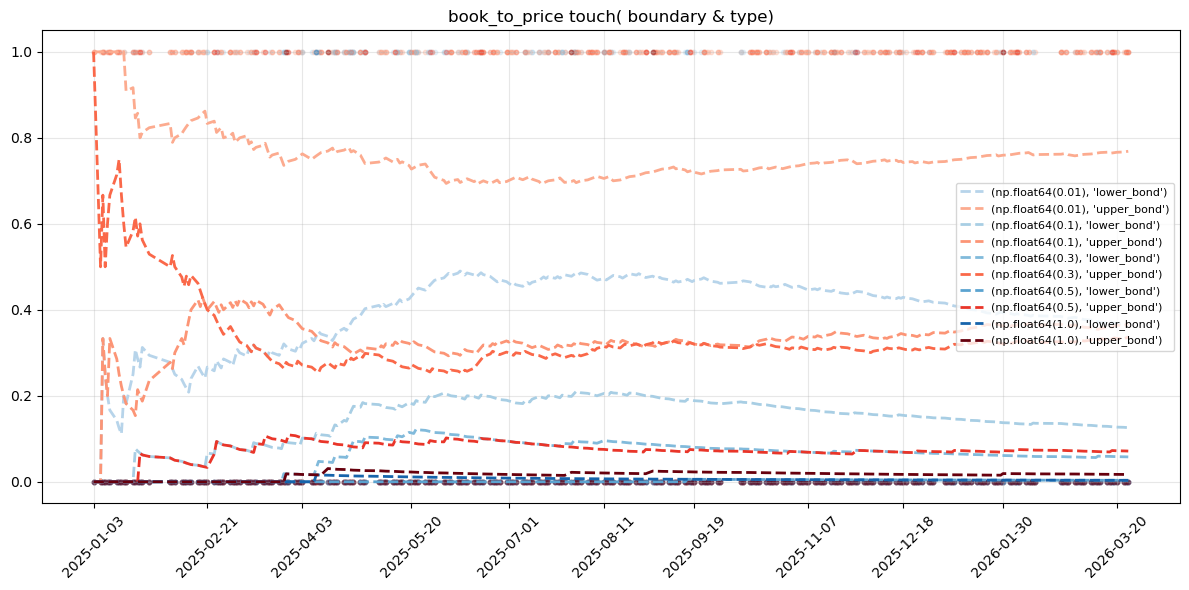

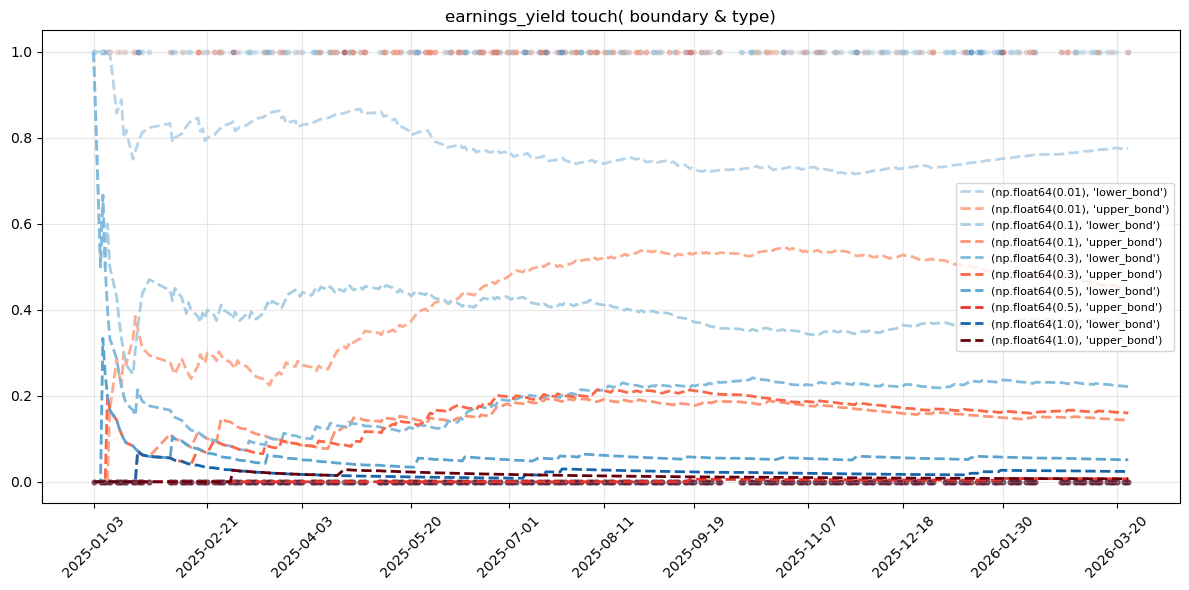

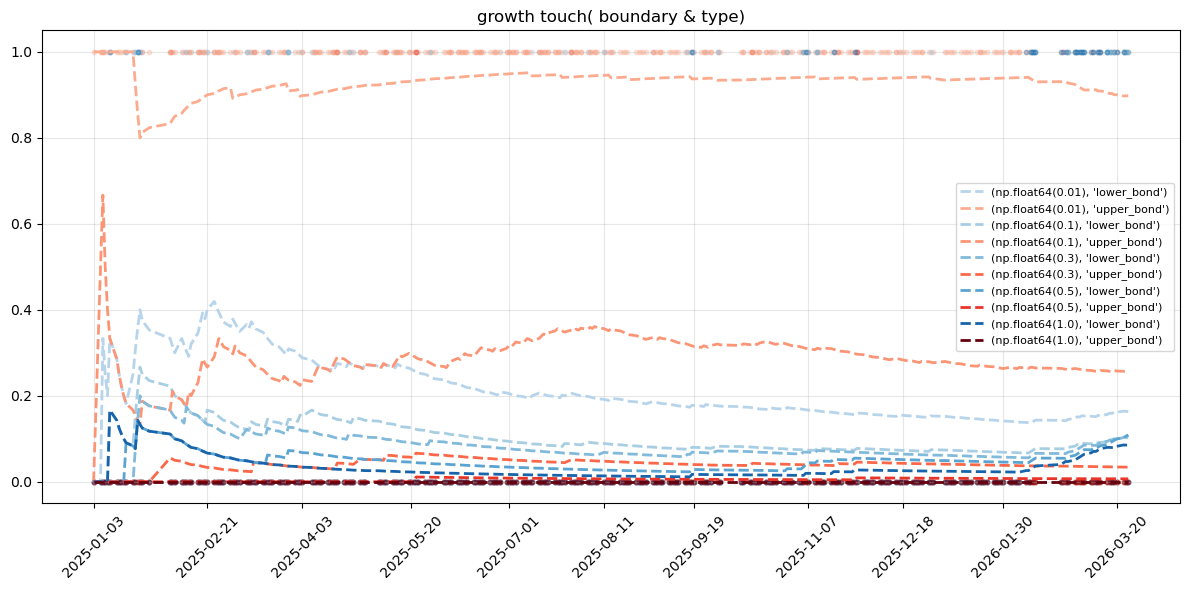

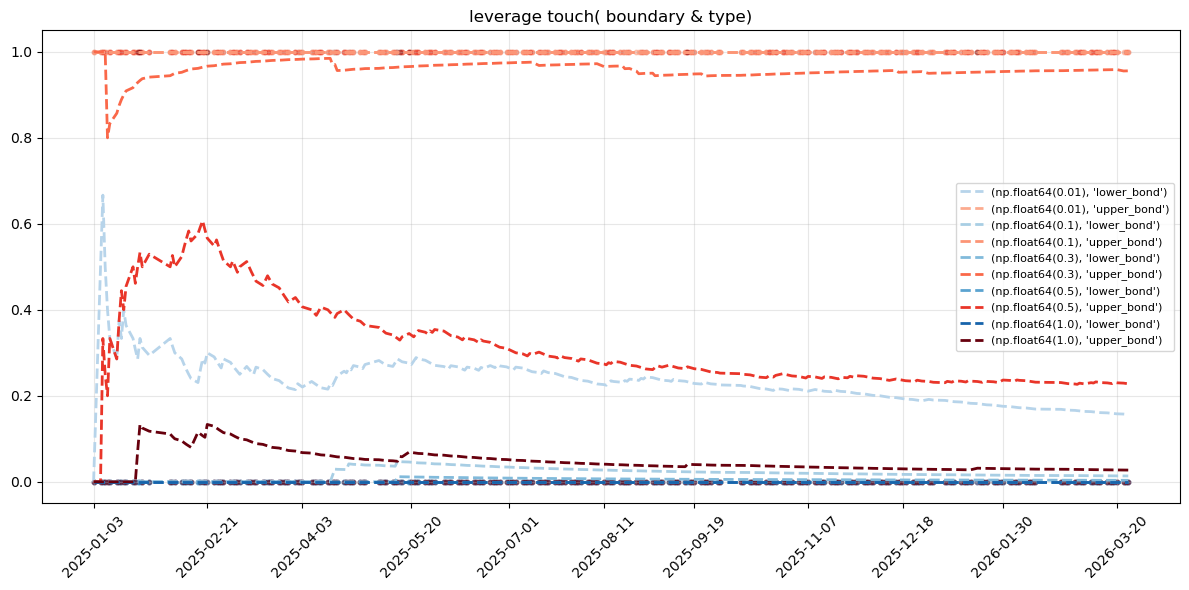

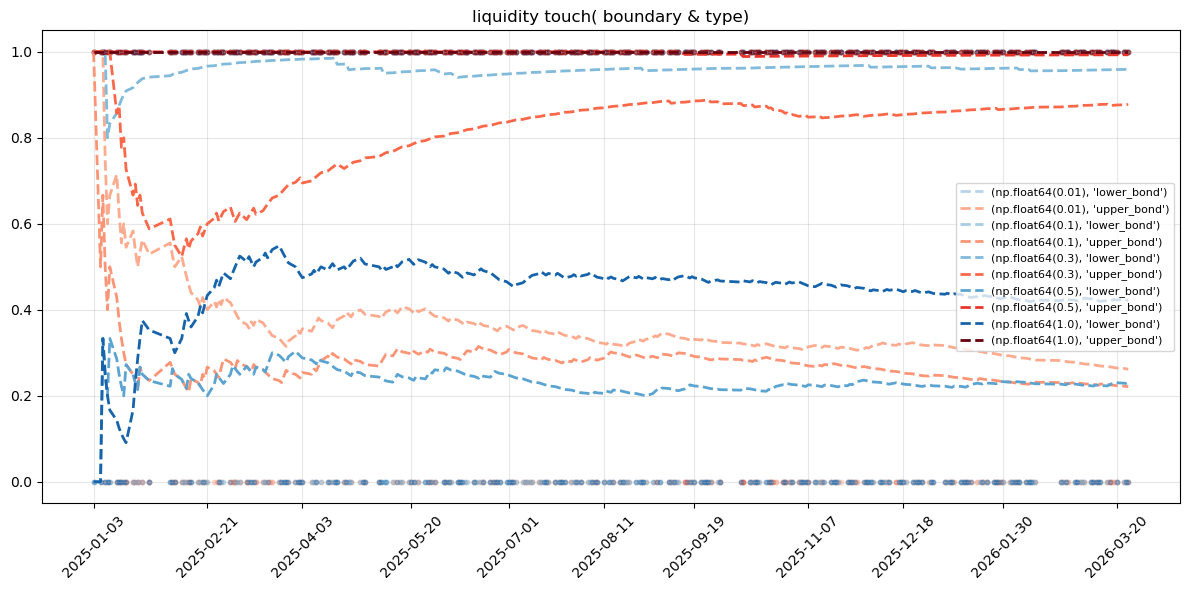

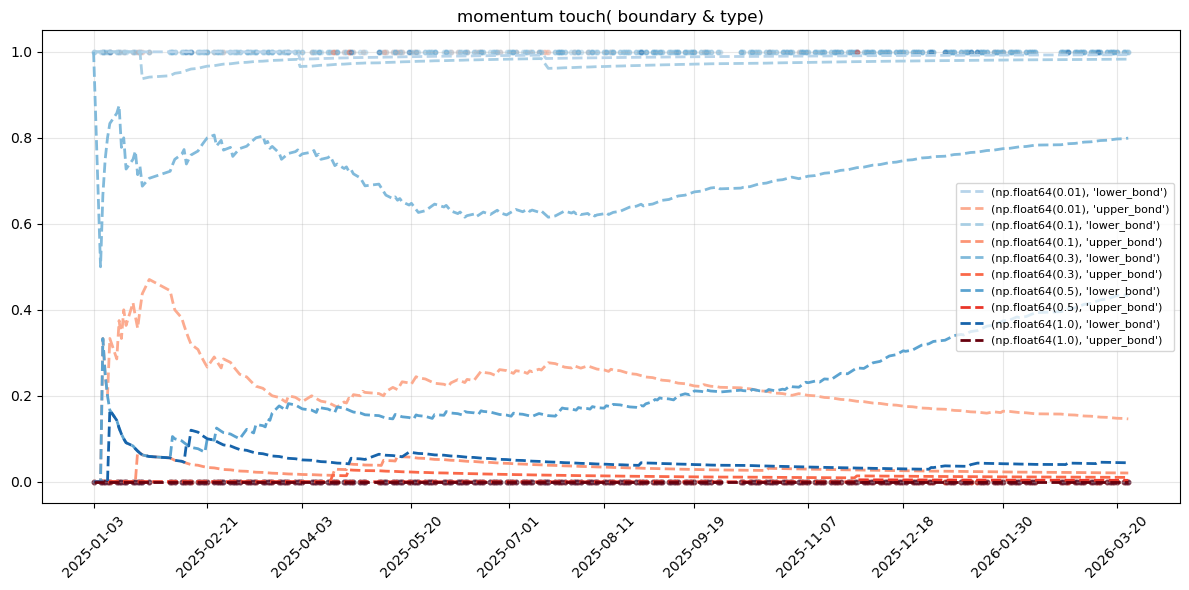

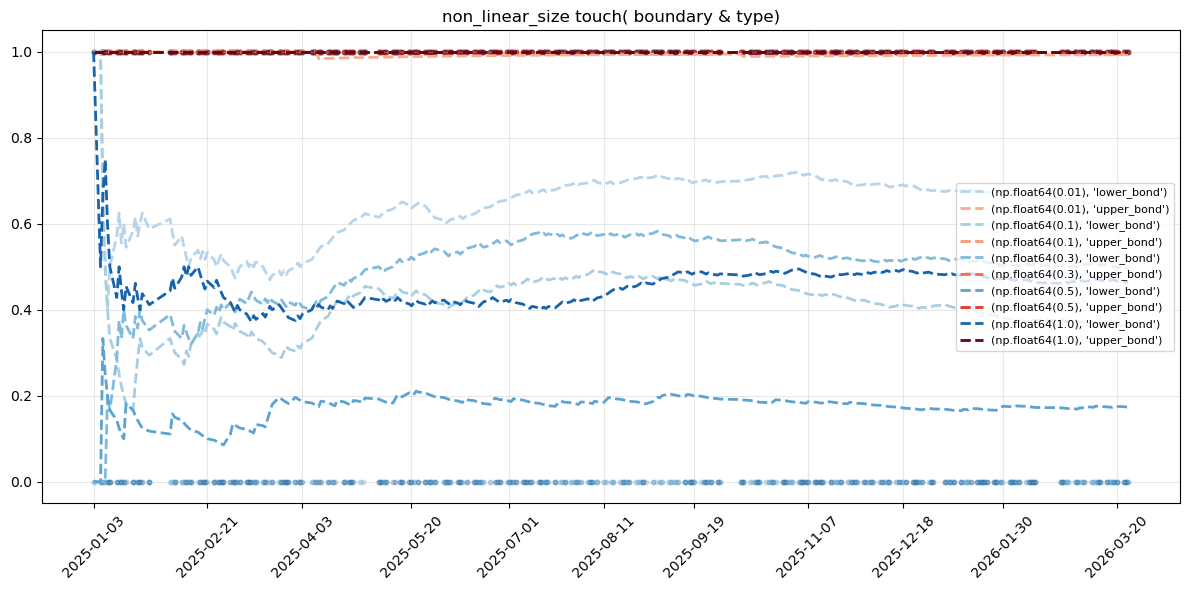

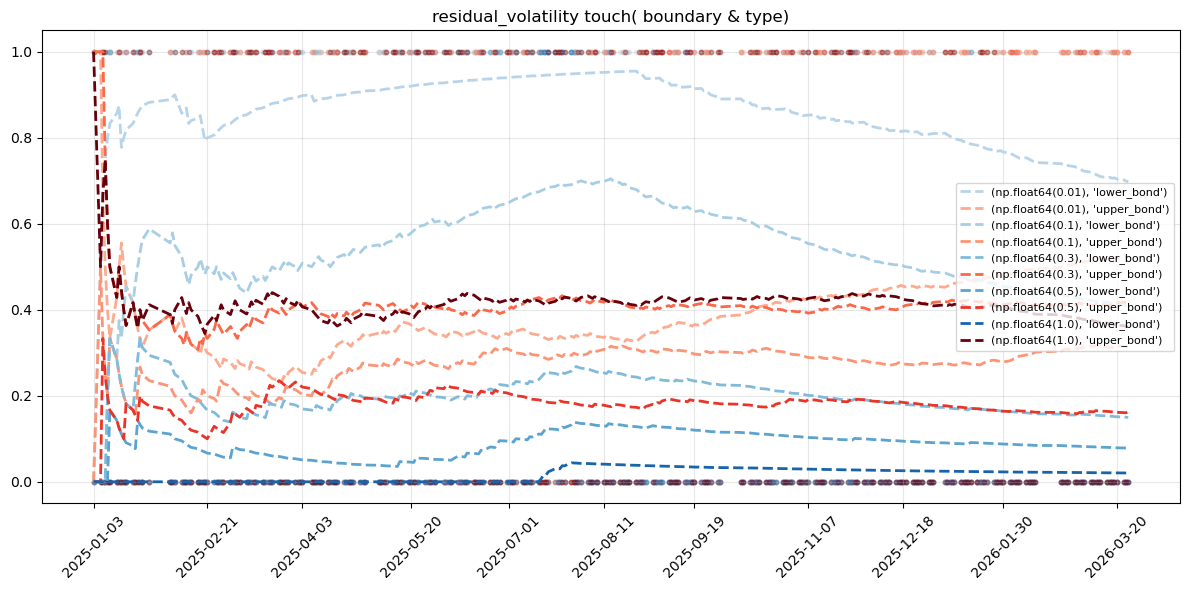

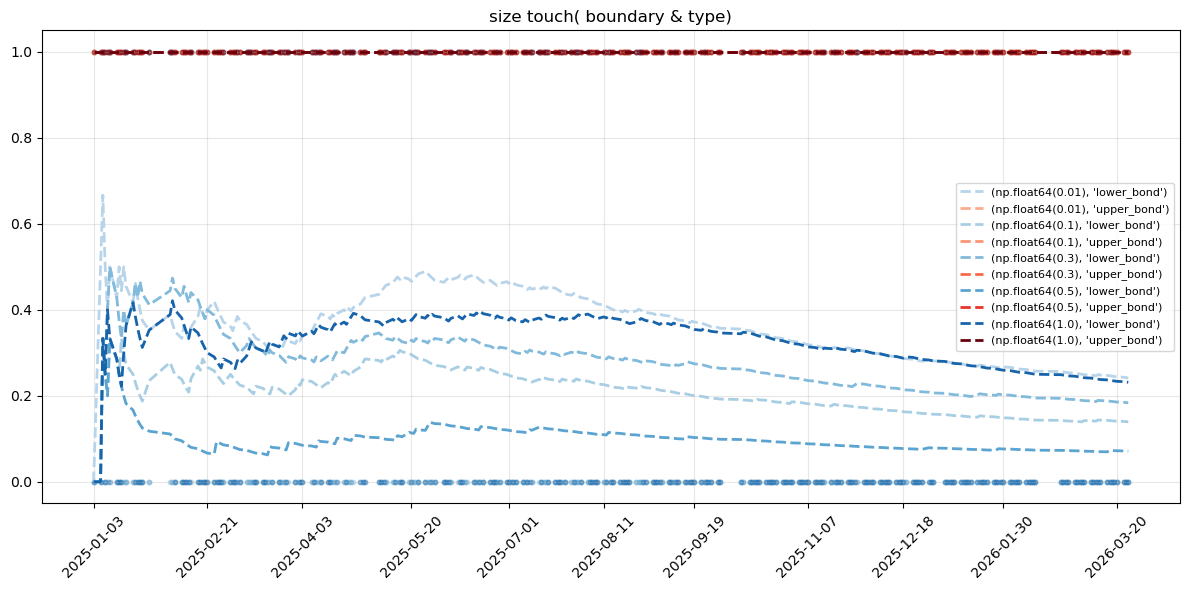

In [5]:
import matplotlib.pyplot as plt
import numpy as np
def parse_tag(tag):
    # tag = "(0.1, 'lower_bond')" 这种
    b, t = eval(tag)
    return float(b), t
def get_color(boundary, typ):
    # 归一化到 0~1
    norm = (boundary - b_min) / (b_max - b_min + 1e-8)
    if typ == 'lower_bond':
        return plt.cm.Blues(0.3 + 0.5 * norm)   # 浅蓝 → 稍深蓝
    else:
        return plt.cm.Reds(0.3 + 0.7 * norm)    # 浅红 → 深红
df = pd.DataFrame(res_dict,columns=["boundary","tradadate","type","factors"])
res = []

for _, row in df.iterrows():
    factors = row['factors']
    onehot = [1 if f in factors else 0 for f in orth_order]
    res.append(list(row) + onehot)

new_cols = list(df.columns) + orth_order
df_new = pd.DataFrame(res, columns=new_cols)
df_new["count"] = df_new[orth_order].sum(axis=1)
for fac in orth_order:
    temp = df_new[["boundary","tradadate","type"]+[fac]]
    res = []
    for g,df_s in temp.groupby(["boundary","type"]):
        tag = str(g)
        df_s.set_index("tradadate",inplace=True)
        df_s = df_s.rename({fac:tag},axis=1)
        res.append(df_s[[tag]])
    df_g = pd.concat(res,axis=1).fillna(0)
    #df_g.to_excel(f"{spedir}/组合优化/{fac}各约束强度的触线情况.xlsx")
    df_g.index= pd.to_datetime(df_g.index)
    # 提取 boundary 分布（用于归一化）
    boundaries = [parse_tag(c)[0] for c in df_g.columns]
    b_min, b_max = min(boundaries), max(boundaries)
    plt.figure(figsize=(12,6))
    # 1️⃣ 散点
    for col in df_g.columns:
        b, t = parse_tag(col)
        color = get_color(b, t)
        
        plt.scatter(df_g.index, df_g[col],
                    s=10, alpha=0.3, color=color)
    # 2️⃣ 趋势线（虚线）
    df_mean = df_g.expanding().mean()
    for col in df_mean.columns:
        b, t = parse_tag(col)
        color = get_color(b, t)
        
        plt.plot(df_mean.index, df_mean[col],
                linestyle='--', linewidth=2,
                color=color, label=col)
    # 美化
    step = max(1, len(df_g)//10)
    plt.xticks(df_g.index[::step], df_g.index[::step].strftime('%Y-%m-%d'), rotation=45)
    plt.title(f"{fac} touch( boundary & type)")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8,loc='center right')
    plt.tight_layout()
    plt.savefig(f"{spedir}/组合优化/{fac}各约束触线图.png")
    #plt.show()
#df["count"] = df.iloc[:,3:].notna().sum(axis=1)
# df.columns = ["boundary","tradadate","type"] + df.columns[3:].tolist()

# for t in ["upper_bond","lower_bond"]:
#     temp = df[df["type"]==t]
#     temp.to_excel(f"{spedir}/组合优化/各约束强度的触线详情{t}.xlsx")
#     df_lst = []
#     for g,df_sm in temp.groupby("boundary"):
#         tag = str(g)
#         df_sm.set_index("tradadate",inplace=True)
#         df_sm = df_sm.rename({"count":tag},axis=1)
#         df_lst.append(df_sm[[tag]])
#     df_g = pd.concat(df_lst,axis=1).fillna(0)
#     #df_g.to_excel(f"{spedir}/组合优化/各约束强度的触线情况{t}.xlsx")

,0.01,0.1,0.3,0.5,1.0,000905
2025-01-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2025-01-03,1.003627,1.003806,1.004144,1.002550,1.001035,0.978700
2025-01-06,1.004563,1.004245,1.002663,1.001306,0.997958,0.978602
2025-01-07,1.008566,1.006086,1.001863,0.999500,0.997965,0.988975
2025-01-08,1.007324,1.004738,0.999674,0.997408,0.997713,0.984822
...,...,...,...,...,...,...
2026-03-18,0.960220,0.958211,0.986090,1.005036,0.943968,1.460994
2026-03-19,0.954594,0.952928,0.980997,0.998444,0.935332,1.421401
2026-03-20,0.944836,0.943043,0.968986,0.983671,0.916619,1.400222
2026-03-23,0.954194,0.952127,0.979527,0.995107,0.931245,1.342673


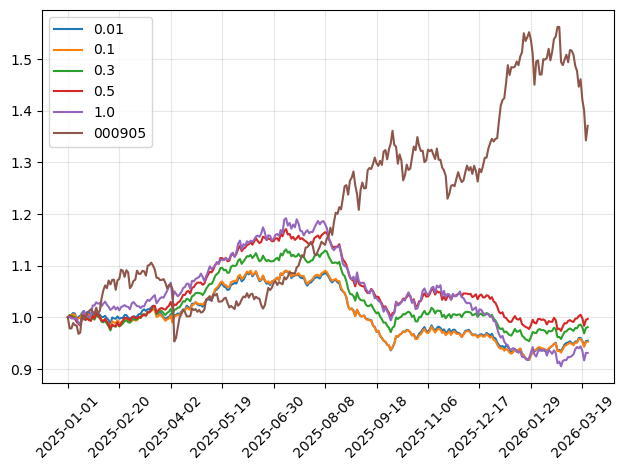

In [3]:
import matplotlib.pyplot as plt
import random

df_500 = pd.read_excel(f"{srcdir}/000905_SH.xlsx")
df_500.index = df_500["日期"].dt.strftime('%Y-%m-%d')
df_500.rename({"涨跌幅":"000905"},axis=1,inplace=True)

ret_df = pd.DataFrame(ret_dict,index=[f[:10] for f in files[1:-1]])
ret_df = ret_df.merge(df_500[["000905"]],left_index=True,right_index=True)
#ret_df = pd.DataFrame(ret_dict.items(),  # 键值对columns=["date", "value"]  # 列名你可以随便改).set_index("date")
temp = pd.DataFrame(0, index=["2025-01-01"], columns=ret_df.columns)
ret0_df = pd.concat([temp, ret_df], ignore_index=False)
ret_cum = (1 + ret0_df).cumprod()
# ret_cum.insert(0,0,0.9) #选
# ret_df.insert(0,0,0.9) #选

plt.plot(ret_cum,label=ret_cum.columns)
step = max(1, len(ret_cum) // 10)  # 最多显示10个刻度
plt.xticks(
    ticks=range(0, len(ret_cum), step),  # 按步长取刻度
    labels=ret_cum.index[::step],       # 对应标签
    rotation=45,                        # 标签倾斜45度（关键！）
    fontsize=10
)
plt.grid(alpha=0.3)  # 加网格更美观
plt.legend(loc='best')
plt.tight_layout()  # 自动适配布局，防止标签截断


# fig, ax1 = plt.subplots(figsize=(10, 6))
# ax1.plot(ret_cum.iloc[:, :-1], label=ret_cum.columns[:-1])
# ax1.legend(loc='best')
# ax1.grid(alpha=0.3)
# ax2 = ax1.twinx()
# ax2.plot(ret_cum.iloc[:, -1], color='red', label=ret_cum.columns[-1])
# ax2.legend(loc='upper right')
# # 统一X轴刻度（你原来的逻辑）
# step = max(1, len(ret_cum) // 10)
# ax1.set_xticks(range(0, len(ret_cum), step))
# ax1.set_xticklabels(ret_cum.index[::step], rotation=45, fontsize=10)
# plt.tight_layout()
# plt.show()
ret_cum

In [ ]:
#画净值曲线备用
import pandas as pd
import matplotlib.pyplot as plt
navdir =  "E:/SJTU/实习/国泰海通/barra因子/result/组合优化"
ret_cum = pd.read_excel(f"{navdir}/minmax_不同std_净值_完整因子部分正交【调方差】+ lam均衡.xlsx",index_col=0)
plt.plot(ret_cum,label=ret_cum.columns)
step = max(1, len(ret_cum) // 10)  # 最多显示10个刻度
plt.xticks(
    ticks=range(0, len(ret_cum), step),  # 按步长取刻度
    labels=ret_cum.index[::step],       # 对应标签
    rotation=45,                        # 标签倾斜45度（关键！）
    fontsize=10
)
plt.grid(alpha=0.3)  # 加网格更美观
plt.legend(loc='best')
plt.tight_layout()  # 自动适配布局，防止标签截断
ret_cum

In [6]:
#简单回测一下业绩
rf = 0.015
res = []
for i in range(1,ret_cum.shape[1]):
    port_nav = ret_cum.iloc[:,i]
    cum_ret = port_nav.iloc[-1] / port_nav.iloc[0] - 1
    ann_ret = (cum_ret + 1)**(252/len(port_nav)) - 1 #daily freq
    ann_vol = ret_df.iloc[:,i].std() * np.sqrt(252)
    sp = (ann_ret - rf) / ann_vol
    maxd = min(port_nav / port_nav.cummax()) - 1
    km = (ann_ret - rf) / abs(maxd) 
    result_dict = {
    '累计收益率': f'{float(cum_ret):.2%}',
    '年化收益率': f'{float(ann_ret):.2%}',
    '年化波动率': f'{float(ann_vol):.2%}',
    '夏普比率': f'{sp:.2f}',
    '最大回撤': f'{maxd:.2%}',
    '卡玛比率': f'{km:.2f}'}
    res.append(pd.Series(result_dict,name=ret_cum.columns[i]))

file_path = f"{spedir}/组合优化/minmax_不同std_净值.xlsx"
with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
    # 第一个表：ret_cum → Sheet1
    ret_cum.to_excel(writer, sheet_name='净值', index=True)
    
    # 第二个表：backtest → Sheet2（你要的）
    pd.concat(res,axis=1).to_excel(writer, sheet_name='回测结果', index=True, header=True)

print("Excel 保存成功！两个工作表都已写入 ✅")

Excel 保存成功！两个工作表都已写入 ✅


In [33]:
regression = pd.DataFrame(reg_lst,columns=["date","slope", "intercept", "r_value", "p_value", "std_err"])
print(regression.iloc[:,1:].mean())
#plt.scatter(regression["date"],regression["p_value"])
#regression.to_excel(f"{spedir}/组合优化/单因子收益对齐.xlsx")

slope        4.542786e-08
intercept    3.744726e-05
r_value      2.433710e-03
p_value      1.840915e-01
std_err      3.358575e-07
dtype: float64


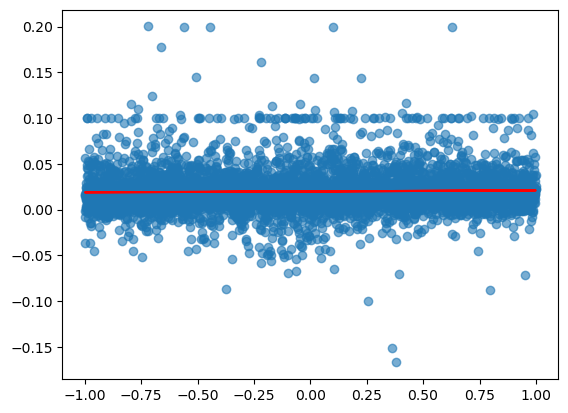

In [51]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.stats import rankdata

x,y = df_reg['D1_orth'], df_reg['ret']
# Step 1: rank（关键）
r = rankdata(x, method='average')   # 1 ~ N
# Step 2: 映射到 (0,1)
u = r / (len(r) + 1)
# Step 3: 映射到 (-1,1)
x_d = 2*u - 1
slope,intercept,*_ = linregress(x_d,y)

plt.scatter(x_d,y,alpha=0.6)
plt.plot(x_d, slope*x_d+intercept, c='r')
plt.show()

In [65]:
desdir = 'E:/SJTU/实习/国泰海通/barra因子/result/组合优化'
n_group = 50
df_reg['group'] = pd.qcut(df_reg[alpha_name].rank(), q=n_group, labels=False)
Rhat_series = df_reg['group'].map(
    df_reg.groupby('group').apply(lambda g: np.average(g['ret'], weights=g['free_mkp']))
)
group_ret = df_reg.groupby('group').apply(lambda g: np.average(g['ret'], weights=g['free_mkp']))
group_ret.to_excel(f"{desdir}/alpha_rank正交_分组收益率.xlsx")
print(group_ret)

group
0     0.018389
1     0.025974
2     0.022956
3     0.022734
4     0.021397
5     0.022554
6     0.016346
7     0.022889
8     0.022123
9     0.034397
10    0.016462
11    0.015773
12    0.021628
13    0.014770
14    0.022561
15    0.020589
16    0.017982
17    0.017585
18    0.020875
19    0.014618
20    0.015396
21    0.012509
22    0.015682
23    0.024086
24    0.018603
25    0.013378
26    0.011717
27    0.019073
28    0.023959
29    0.022111
30    0.021843
31    0.017556
32    0.012873
33    0.019596
34    0.014253
35    0.024762
36    0.016346
37    0.021099
38    0.021198
39    0.021678
40    0.022614
41    0.013037
42    0.021973
43    0.007250
44    0.012159
45    0.017182
46    0.022057
47    0.012900
48    0.007071
49    0.021016
dtype: float64


因子底层逻辑、与风险因子的相关性确认

In [24]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")
srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/"
adir = "E:/SJTU/实习/国泰海通/barra因子/result/延迟alpha"
facdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/fac_ret/whole_mkt"
desdir = "E:/SJTU/实习/国泰海通/barra因子/result/组合优化/延迟因子_barra"

risk_factor = "momentum"
candidate_factor = 'D1_orth'
df_fac = pd.read_pickle(f"{facdir}/factor_returns_20_2603.pkl")
#files = os.listdir(f"{srcdir}/alpha/candidate")
alpha_dict = pd.read_pickle(f"{adir}/ortho_delay_measures_2024_2026_dict.pkl")
mcp_dict = pd.read_pickle(f"{srcdir}/stk_mcp/全A_freemcp_25_26D_dict.pkl")
ret_dict = pd.read_pickle(f"{srcdir}/stk_ret/全A_ret_24_2603D_dict.pkl")
ret_lst = {}

def calculate_candidate_hist_factor_return(df, candidate_col=candidate_factor, capital_col='free_mkp', return_col='ret'):
    """
    计算candidate_HIST因子的收益率
    步骤：
    1. 将股票根据candidate_HIST分为大中小三组（30%、40%、30%）
    2. 每个组再根据capital分为大市值、小市值两组
    3. 计算六个组的市值加权收益率
    4. 因子收益率 = 大组平均 - 小组平均
    
    参数：
    df: 包含股票数据的DataFrame，必须包含candidate_HIST、capital和return列
    candidate_col: candidate_HIST因子列名
    capital_col: 市值列名
    return_col: 收益率列名
    
    返回：
    factor_return: candidate_HIST因子的收益率
    """
    # 1. 根据candidate_HIST分组
    df['candidate_group'] = pd.qcut(df[candidate_col], q=[0, 0.3, 0.7, 1], labels=['small', 'medium', 'large'])
    
    # 2. 每个candidate组内根据capital分组
    grouped = df.groupby('candidate_group')
    groups = []
    
    for name, group in grouped:
        # 每组内按capital分为大市值和小市值
        group['cap_group'] = pd.qcut(group[capital_col], q=3, labels=['small_cap','medium_cap', 'large_cap'])
        groups.append(group)
    
    df_with_groups = pd.concat(groups)
    
    # 3. 计算六个组的市值加权收益率
    # 计算每个组的总市值
    df_with_groups['weight'] = df_with_groups[capital_col] / df_with_groups.groupby(['candidate_group', 'cap_group'])[capital_col].transform('sum')
    # 计算加权收益率
    df_with_groups['weighted_return'] = df_with_groups[return_col] * df_with_groups['weight']
    # 计算每个组的收益率
    group_returns = df_with_groups.groupby(['candidate_group', 'cap_group'])['weighted_return'].sum()
    
    # 4. 计算因子收益率
    # 大组的大小市值平均
    large_avg = (group_returns.loc[('large', 'small_cap')] + group_returns.loc[('large', 'medium_cap')] + group_returns.loc[('large', 'large_cap')]) / 3
    # 小组的大小市值平均
    small_avg = (group_returns.loc[('small', 'small_cap')] + group_returns.loc[('small', 'medium_cap')] + group_returns.loc[('small', 'large_cap')]) / 3
    # 因子收益率
    factor_return = large_avg - small_avg
    
    return factor_return

for dt in alpha_dict.keys():
    if dt < pd.Timestamp(2025,1,1):
        continue
    #str_dt = dt.strftime('%Y-%m-%d')
    df_a = alpha_dict[dt]#pd.read_pickle(f"{srcdir}/alpha/macd/{dt}.pkl")    
    df_b = mcp_dict[dt]#pd.read_pickle(f"{srcdir}/base_data/whole_mkt/{str_dt}.pkl")
    df_c = ret_dict[dt].rename(columns={"value":"ret"})
    df = df_a.merge(df_b, on="order_book_id").merge(df_c, on="order_book_id")
    alpha_ret = calculate_candidate_hist_factor_return(df)
    ret_lst[dt] = alpha_ret
s_alpha = pd.Series(ret_lst.values(), index=pd.to_datetime(list(ret_lst.keys())),name='candidate')
print("candidate alpha's t-value:",s_alpha.mean() / s_alpha.std() * np.sqrt(len(s_alpha)))
df_comb = pd.merge(s_alpha,df_fac.iloc[:,:11],left_index=True,right_index=True) #df_fac["momentum"]
df_corr = df_comb.corr()
df_corr.to_excel(f"{desdir}/orth_delayret_corr_facret.xlsx")
df_corr

candidate alpha's t-value: -7.638895623068726


,candidate,beta,book_to_price,comovement,earnings_yield,growth,leverage,liquidity,momentum,non_linear_size,residual_volatility,size
candidate,1.000000,0.348182,0.188746,0.584034,-0.175711,-0.084364,0.060759,0.220631,-0.146174,-0.019732,0.159566,0.068036
beta,0.348182,1.000000,0.058297,0.609535,-0.104916,0.216881,-0.220282,0.132179,-0.020967,0.066431,0.466006,0.243326
book_to_price,0.188746,0.058297,1.000000,0.109830,-0.017859,-0.182869,0.220383,0.064937,-0.221930,-0.116548,0.181401,0.006897
comovement,0.584034,0.609535,0.109830,1.000000,-0.097193,0.070723,0.018692,0.327472,0.021280,0.068466,0.141201,-0.003593
earnings_yield,-0.175711,-0.104916,-0.017859,-0.097193,1.000000,0.136567,-0.050375,-0.370572,0.134115,0.002900,-0.048952,0.033419
growth,-0.084364,0.216881,-0.182869,0.070723,0.136567,1.000000,-0.313739,-0.269990,0.353867,0.178665,-0.089466,0.303902
leverage,0.060759,-0.220282,0.220383,0.018692,-0.050375,-0.313739,1.000000,0.068737,-0.143457,-0.047901,-0.112148,-0.168209
liquidity,0.220631,0.132179,0.064937,0.327472,-0.370572,-0.269990,0.068737,1.000000,-0.262902,0.131736,0.162843,0.118212
momentum,-0.146174,-0.020967,-0.221930,0.021280,0.134115,0.353867,-0.143457,-0.262902,1.000000,-0.061161,-0.469020,-0.144092
non_linear_size,-0.019732,0.066431,-0.116548,0.068466,0.002900,0.178665,-0.047901,0.131736,-0.061161,1.000000,0.031862,0.428463
